# Gram-Schmidt and Modified Gram-Schmidt algorithms

In [1]:
import numpy as np
from numpy.typing import NDArray
from py_mods.src.SCF.plot_utilities import plot_map

# Regular Gram-Schmidt Algorithm

The regular Gram-Schmidt algorithm is a method for orthonormalizing a set of vectors in an inner product space. The process takes a finite, linearly independent set of vectors and generates an orthonormal set of vectors that spans the same subspace. The algorithm considers a set of vectors  $\{v_1, v_2, \ldots, v_n\}$ and produces an orthonormal set $\{e_1, e_2, \ldots, e_n\}$. 

The first vector of the orthogonal basis is defined as just the normalized first vector of the original set:

$$
e_1 = \frac{v_1}{\|v_1\|}
$$

After we have obtained this vector, the Gram-Schmidt algorithm proceeds iteratively. As the idea is to form an orthonormal set, the following procedure is to eliminate any component of the previous basis vector from the current vector. This is done by projecting the current vector onto the previous orthogonal vector and subtracting the projection from the current vector. The projection operator is defined as:

$$
P_u(v) = \frac{\braket{v,u}}{\braket{u,u}} u
$$

Where $P_u$ indicates that the projection is done over the vector $u$ and $\braket{ \cdot, \cdot}$ a well-defined inner product. Using this operator, the second orthogonal vector is computed as:

$$
u_2 = v_2 - P_{e_1}(v_2)
$$

And normalizing it gives us the second orthonormal vector:

$$
e_2 = \frac{u_2}{\|u_2\|}
$$

Now this procedure is repeated until the whole basis is spanned. For the $i$-th vector, the orthogonal vector is computed as:
$$
u_i = v_i - \sum_{j=1}^{i-1} P_{e_j}(v_i)
$$

And the orthonormal basis is obtained. 

---

## Numerical unstability of the classical Gram-Schmidt algorithm

An example of three linearly independent vectors that are unstable using the classical Gram-Schmidt algorithm is the Lauchly matrix:

$$
\begin{pmatrix}
          1 & 1 & 1 \\
\varepsilon & 0 & 0 \\
1 & \varepsilon & 1 \\
1 & 1 & \varepsilon \\ 
\end{pmatrix}
$$

When performing a classical GM orthonormalization, the orthonormalization usually fails, as we will see here:

In [2]:
eps = 1e-10 

unst_mat = np.array([
    [  1,   1,   1],
    [eps,   0,   0],
    [  0, eps,   0],
    [  0,   0, eps],
], dtype=np.complex128)

As mentioned, the GS procedure works for any vector space with a well defined inner product. Here we will use the complex inner product (c-product), Where:
$$
(c| = |c)^T
$$

Where the vector $|c) \in \mathbb{C}^n$. Therefore, the norm is defined as:

$$
\|c\| = \sqrt{(c|c)} = \sqrt{\sum_i^n c_i^2}
$$

In [3]:
def c_norm(u: NDArray[np.complex128]) -> np.complex128:
    """
    Calculate c-norm (sqrt(u.u)).

    Parameters
    ----------
    u : NDArray[np.complex128]
        Input vector.

    Returns
    -------
    np.complex128
        Calculated norm.
    """
    return np.sqrt(np.dot(u, u))

And the c-product is defined as:
$$
(c_i|c_j) = \sum^n_a c_{ia} \cdot c_{ja}
$$

In [4]:
def c_dot(u: NDArray[np.complex128], v: NDArray[np.complex128]) -> np.complex128:
    """
    Calculate c-dot product.

    Parameters
    ----------
    u : NDArray[np.complex128]
        First input vector.
    v : NDArray[np.complex128]
        Second input vector.

    Returns
    -------
    np.complex128
        Calculated dot product.
    """
    return np.dot(u, v)

The projection operation is defined as before:

$$
P_u(v) = \frac{(v|u)}{(u|u)} u
$$

In [5]:
def c_projector(
    u: NDArray[np.complex128], v: NDArray[np.complex128]
) -> NDArray[np.complex128]:
    """
    Calculate c-projection of v onto u.

    Parameters
    ----------
    u : NDArray[np.complex128]
        Vector onto which v is projected.
    v : NDArray[np.complex128]
        Vector to be projected onto u.

    Returns
    -------
    NDArray[np.complex128]
        Projected vector.
    """
    num = np.dot(v, u)  # c-product (no conjugation)
    den = np.dot(u, u)
    if abs(den) < 1e-14:
        return np.zeros_like(v)
    return (num / den) * u

Finaly, the classical GS algorithm is defined as:

In [6]:
def gram_schmidt(v: NDArray[np.complex128]) -> NDArray[np.complex128]:
    """
    Apply Gram-Schmidt orthonormalization.

    Parameters
    ----------
    v : NDArray[np.complex128]
        Input vectors as columns.

    Returns
    -------
    NDArray[np.complex128]
        Orthonormalized vectors as columns.
    """
    # initialize the space
    dim, vectors = v.shape
    e = np.zeros((dim, vectors), dtype=np.complex128)
    u = np.zeros((dim, vectors), dtype=np.complex128)

    # obtain first basis vector 
    u[:,0] = v[:,0].copy()
    e[:,0] = v[:,0] / c_norm(v[:,0])

    # for every remaining vector, subtract the projection of the previous basis vectors
    for i in range(1, vectors):
        v_i = v[:,i]
        proj = np.zeros(dim, dtype=np.complex128)
        for j in range(i):
            proj += c_projector(u[:,j], v_i)
        u[:,i] = v_i - proj

        # and normalize to get the next basis vector
        e[:,i] = u[:,i] / c_norm(u[:,i])

    return e

Let's try with the Lauchly matrix:

In [7]:
RGM_sol_GS = gram_schmidt(unst_mat)
print('Product 1 and 1:', c_dot(RGM_sol_GS[:,0], RGM_sol_GS[:,0]))
print('Product 1 and 2:', c_dot(RGM_sol_GS[:,0], RGM_sol_GS[:,1]))
print('Product 1 and 3:', c_dot(RGM_sol_GS[:,0], RGM_sol_GS[:,2]))
print('Product 2 and 2:', c_dot(RGM_sol_GS[:,1], RGM_sol_GS[:,1]))
print('Product 2 and 3:', c_dot(RGM_sol_GS[:,1], RGM_sol_GS[:,2]))
print('Product 3 and 3:', c_dot(RGM_sol_GS[:,2], RGM_sol_GS[:,2]))


Product 1 and 1: (1+0j)
Product 1 and 2: (-7.071067811865477e-11+0j)
Product 1 and 3: (-7.071067811865477e-11+0j)
Product 2 and 2: (1.0000000000000002+0j)
Product 2 and 3: (0.5000000000000001+0j)
Product 3 and 3: (1.0000000000000002+0j)


Or in matricial form, to visualize it:

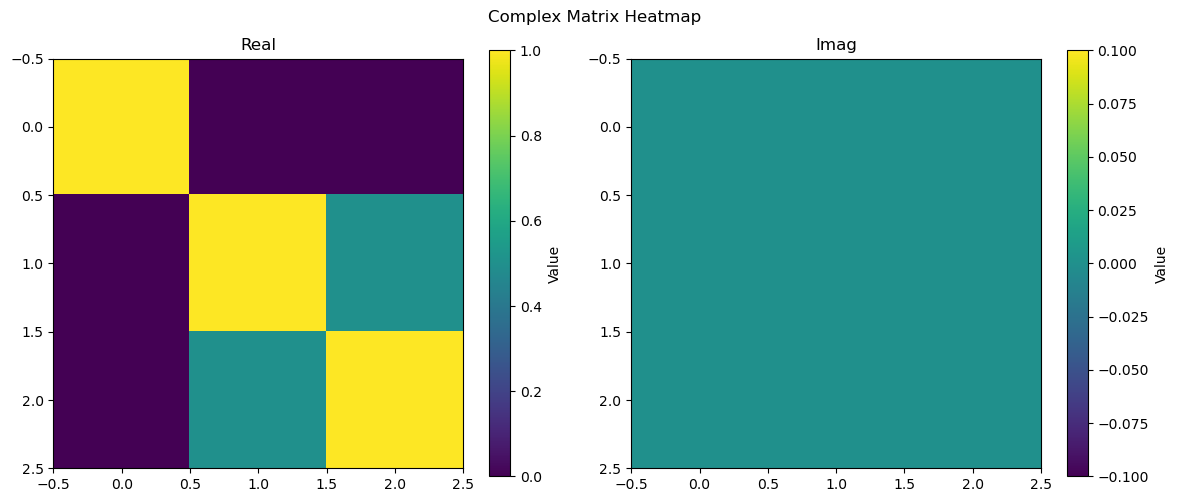

In [8]:
norms = RGM_sol_GS.T @ RGM_sol_GS
plot_map(norms)

Where we can clearly see that the products $(e_2|e_3)$ and $(e_3|e_2)$ are clearly not orthogonal as they should. 

---

# Modified Gram-Schmidt algorithm
The Modified Gram-Schmidt algorithm is a numerically stable variant of the classical GS. The variation comes from the way the orthogonal vectors are computed. Instead of projecting the original vectors onto each of the previous orthogonal vectors, the MGS algorithm projects the already basis vectors onto the current vector at each step. The first orthonormal vector is computed the same way as in the classical GS:

$$
e_1 = \frac{v_1}{\|v_1\|}
$$

And the second orthogonal vector is computed as:
$$
u_2 = v_2 - P_{e_1}(v_2)
$$
$$
e_2 = \frac{u_2}{\|u_2\|}
$$ 

However, instead of stopping here, we will perform this for each of the previous basis vectors. This way we obtain the vector:
$$
u_i^{(k)} = u_i^{(k-1)} - P_{e_k}(u_i^{(k-1)})
$$

Where $u_i^{(0)} = v_i$ and $k = 1, 2, \ldots, i-1$ indicate the "$k$-th" iteration of the original vector, which is orthogonal to the first $k$ basis vectors. Then we obtain the $i$-th basis vector as:

$$
e_i = \frac{u_i^{(i-1)}}{\|u_i^{(i-1)}\|}
$$

The MGS routine is defined as:

In [9]:
def modified_gram_schmidt(v: NDArray[np.complex128]) -> NDArray[np.complex128]:
    """
    Apply Modified Gram-Schmidt orthonormalization.

    Parameters
    ----------
    v : NDArray[np.complex128]
        Input vectors as columns.

    Returns
    -------
    NDArray[np.complex128]
        Orthonormalized vectors.
    """

    # exctract number of dimensions and of vectors (array in column form has a shape ())
    dim, vectors = v.shape
    e = np.zeros((dim, vectors), dtype=np.complex128)

    # copy the original vectors to modify them at each step
    v_copy = v.astype(np.complex128)

    for i in range(vectors):
        # normalize the i-th basis vector
        e[:,i] = v_copy[:,i] / c_norm(v_copy[:,i])

        # remove component in this direction of all the remaining vectors
        for j in range(i + 1, vectors):
            proj = c_projector(e[:,i], v_copy[:,j])
            v_copy[:,j] -= proj

    return e

In [10]:
RGM_sol = modified_gram_schmidt(unst_mat)
print('Product 1 and 1:', c_dot(RGM_sol[:,0], RGM_sol[:,0]))
print('Product 1 and 2:', c_dot(RGM_sol[:,0], RGM_sol[:,1]))
print('Product 1 and 3:', c_dot(RGM_sol[:,0], RGM_sol[:,2]))
print('Product 2 and 2:', c_dot(RGM_sol[:,1], RGM_sol[:,1]))
print('Product 2 and 3:', c_dot(RGM_sol[:,1], RGM_sol[:,2]))
print('Product 3 and 3:', c_dot(RGM_sol[:,2], RGM_sol[:,2]))

Product 1 and 1: (1+0j)
Product 1 and 2: (-7.071067811865477e-11+0j)
Product 1 and 3: (-4.082482904638631e-11+0j)
Product 2 and 2: (1.0000000000000002+0j)
Product 2 and 3: (-2.0810397330994324e-17+0j)
Product 3 and 3: (1.0000000000000002+0j)


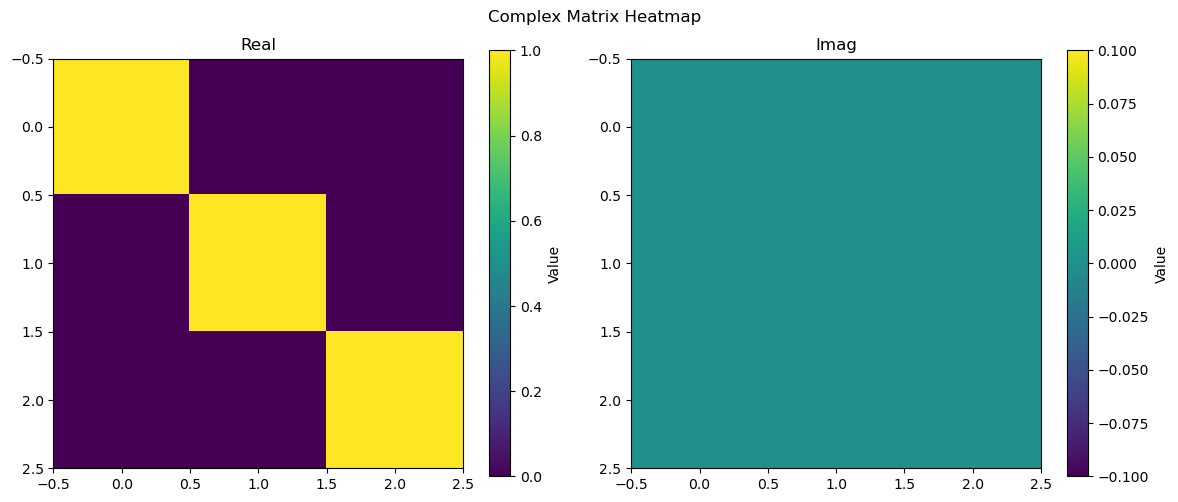

In [11]:
norms = RGM_sol.T @ RGM_sol
plot_map(norms)



Which works fantasticaly in this case.

---

References:
-----
- [Intuitive explanation of why the modified Gram-Schmidt is more stable than the classical one?](https://math.stackexchange.com/questions/3913710/intuitive-explanation-of-why-the-modified-gram-schmidt-is-more-stable-than-the-c)
- [Classical Gram-Schmidt for matrix A](https://math.stackexchange.com/questions/2936035/classical-gram-schmidt-for-matrix-a/2936110#2936110)
- [Wikipedia](https://en.wikipedia.org/wiki/Gram%E2%80%93Schmidt_process)
